In [2]:
from ultralytics import YOLO
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
def calculate_iou(box1, box2):
    """box format: [x1, y1, x2, y2]"""
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2

    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)

    inter_area = max(0, inter_x_max - inter_x_min) * max(0, inter_y_max - inter_y_min)

    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area > 0 else 0


def yolo_to_xyxy(yolo_box, img_width, img_height):
    """YOLO 歸一化格式 [cx, cy, w, h] -> [x1, y1, x2, y2]"""
    cx, cy, w, h = yolo_box
    x1 = (cx - w / 2) * img_width
    y1 = (cy - h / 2) * img_height
    x2 = (cx + w / 2) * img_width
    y2 = (cy + h / 2) * img_height
    return [x1, y1, x2, y2]


def box_center(box):
    """[x1, y1, x2, y2] -> center (cx, cy)"""
    return np.array([(box[0] + box[2]) / 2, (box[1] + box[3]) / 2])

In [4]:
def get_nodule_records(result, image_path, patient_id, iou_threshold=0.5):
    """
    以 nodule 為單位，回傳一張圖片中每個 nodule 的配對結果。

    每筆 record 包含:
      patient_ID, file_name, match_type ('TP'/'FP'/'FN'),
      pred_box, gt_box (xyxy or None), iou, conf, center_distance (or None)

    規則:
      - pred nodule 與 GT nodule IoU >= threshold  -> TP
      - pred nodule 與 GT maybe_nodule IoU >= threshold -> 忽略
      - pred nodule 無匹配                         -> FP
      - GT nodule 無匹配                           -> FN
    """
    img_height, img_width = result.orig_shape
    file_name = Path(image_path).name

    # --- 預測框 ---
    pred_boxes, pred_classes, pred_confs = [], [], []
    if result.boxes is not None and len(result.boxes) > 0:
        pred_boxes   = result.boxes.xyxy.cpu().numpy()
        pred_classes = result.boxes.cls.cpu().numpy()
        pred_confs   = result.boxes.conf.cpu().numpy()

    # --- GT 標籤 ---
    label_path = (image_path
                  .replace('/images/', '/labels/')
                  .replace('.png', '.txt')
                  .replace('.jpg', '.txt'))
    gt_boxes_nodule, gt_boxes_maybe = [], []

    if Path(label_path).exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                class_id, cx, cy, w, h = map(float, parts[:5])
                xyxy = yolo_to_xyxy([cx, cy, w, h], img_width, img_height)
                if class_id == 0:
                    gt_boxes_nodule.append(xyxy)
                elif class_id == 1:
                    gt_boxes_maybe.append(xyxy)

    pred_nodule_idx = [i for i, cls in enumerate(pred_classes) if cls == 0]

    # --- 匹配 ---
    matched_gt = set()
    matched_pred = set()
    ignored_pred = set()
    matched_pairs = []  # (pred_idx, gt_idx, iou)

    for i in pred_nodule_idx:
        pred_box = pred_boxes[i]
        best_iou, best_j = 0, -1

        for j, gt_box in enumerate(gt_boxes_nodule):
            if j in matched_gt:
                continue
            iou = calculate_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou, best_j = iou, j

        if best_iou >= iou_threshold:
            matched_gt.add(best_j)
            matched_pred.add(i)
            matched_pairs.append((i, best_j, best_iou))
        else:
            maybe_iou = max(
                (calculate_iou(pred_box, gb) for gb in gt_boxes_maybe),
                default=0
            )
            if maybe_iou >= iou_threshold:
                ignored_pred.add(i)

    # --- 建立 records ---
    records = []
    base = {'patient_ID': patient_id, 'file_name': file_name}

    # TP
    for pred_i, gt_j, iou in matched_pairs:
        pred_box = pred_boxes[pred_i].tolist()
        gt_box   = gt_boxes_nodule[gt_j]
        records.append({**base,
            'match_type': 'TP',
            'pred_box':   pred_box,
            'gt_box':     gt_box,
            'iou':        iou,
            'conf':       float(pred_confs[pred_i]),
            'center_distance': float(np.linalg.norm(box_center(pred_box) - box_center(gt_box)))
        })

    # FP
    for i in pred_nodule_idx:
        if i not in matched_pred and i not in ignored_pred:
            records.append({**base,
                'match_type': 'FP',
                'pred_box':   pred_boxes[i].tolist(),
                'gt_box':     None,
                'iou':        0.0,
                'conf':       float(pred_confs[i]),
                'center_distance': None
            })

    # FN
    for j, gt_box in enumerate(gt_boxes_nodule):
        if j not in matched_gt:
            records.append({**base,
                'match_type': 'FN',
                'pred_box':   None,
                'gt_box':     gt_box,
                'iou':        0.0,
                'conf':       None,
                'center_distance': None
            })

    # 若圖片沒有 GT 也沒有預測，補一筆空記錄方便 image-wise 聚合
    if not records:
        records.append({**base,
            'match_type': 'TN',
            'pred_box': None, 'gt_box': None,
            'iou': None, 'conf': None, 'center_distance': None
        })

    return records

In [5]:
def compute_metrics_from_counts(tp, fp, fn):
    eta = 1e-9
    recall    = tp / (tp + fn + eta)
    precision = tp / (tp + fp + eta)
    f1        = 2 * precision * recall / (precision + recall + eta)
    return recall, precision, f1


def get_image_metrics(nodule_df):
    """Image-wise metrics: 每張圖片各自計算 recall / precision / F1"""
    counts = (
        nodule_df[nodule_df['match_type'].isin(['TP', 'FP', 'FN'])]
        .groupby(['file_name', 'match_type'])
        .size()
        .unstack(fill_value=0)
    )
    for col in ['TP', 'FP', 'FN']:
        if col not in counts:
            counts[col] = 0

    counts[['recall', 'precision', 'f1']] = [
        compute_metrics_from_counts(row.TP, row.FP, row.FN)
        for _, row in counts.iterrows()
    ]
    return counts


def get_patient_metrics(nodule_df):
    """Patient-wise metrics: 把同一病患的所有 nodule 合併後計算"""
    counts = (
        nodule_df[nodule_df['match_type'].isin(['TP', 'FP', 'FN'])]
        .groupby(['patient_ID', 'match_type'])
        .size()
        .unstack(fill_value=0)
    )
    for col in ['TP', 'FP', 'FN']:
        if col not in counts:
            counts[col] = 0

    counts[['recall', 'precision', 'f1']] = [
        compute_metrics_from_counts(row.TP, row.FP, row.FN)
        for _, row in counts.iterrows()
    ]
    return counts


def summarize(nodule_df):
    """印出 image-wise 與 patient-wise 的平均指標，以及 TP center distance 統計"""
    img_df = get_image_metrics(nodule_df)
    pat_df = get_patient_metrics(nodule_df)

    print(f"  Image-wise   | recall={img_df['recall'].mean():.4f}  "
          f"precision={img_df['precision'].mean():.4f}  "
          f"F1={img_df['f1'].mean():.4f}")
    print(f"  Patient-wise | recall={pat_df['recall'].mean():.4f}  "
          f"precision={pat_df['precision'].mean():.4f}  "
          f"F1={pat_df['f1'].mean():.4f}")

    tp_dist = nodule_df.loc[nodule_df['match_type'] == 'TP', 'center_distance'].dropna()
    if len(tp_dist) > 0:
        print(f"  Center dist  | n={len(tp_dist)}  "
              f"mean={tp_dist.mean():.2f}  "
              f"median={tp_dist.median():.2f}  "
              f"std={tp_dist.std():.2f}  "
              f"max={tp_dist.max():.2f}")
    else:
        print("  Center dist  | no TP found")

    return img_df, pat_df

In [6]:
def calculate_ap(nodule_df):
    """
    計算 Average Precision (AP)，使用 101-point interpolation (COCO style)。

    流程:
      1. 取所有 TP + FP，依 conf 由高到低排序
      2. 逐步累計 TP/FP，計算每點的 precision / recall
      3. 對 recall [0, 0.01, 0.02, ..., 1.0] 101 個點取 max precision，取平均
    """
    total_gt = nodule_df['match_type'].isin(['TP', 'FN']).sum()
    if total_gt == 0:
        return 0.0, np.array([]), np.array([])

    preds = (
        nodule_df[nodule_df['match_type'].isin(['TP', 'FP'])]
        .dropna(subset=['conf'])
        .sort_values('conf', ascending=False)
        .reset_index(drop=True)
    )

    if len(preds) == 0:
        return 0.0, np.array([0.0]), np.array([0.0])

    tp_cumsum = (preds['match_type'] == 'TP').cumsum().values
    fp_cumsum = (preds['match_type'] == 'FP').cumsum().values

    recalls    = tp_cumsum / total_gt
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum)

    # 101-point interpolation
    ap = 0.0
    for thr in np.linspace(0, 1, 101):
        p_at_thr = precisions[recalls >= thr]
        ap += p_at_thr.max() if len(p_at_thr) > 0 else 0.0
    ap /= 101

    return ap, recalls, precisions


def plot_pr_curve(recalls, precisions, ap, iou_threshold):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recalls, precisions, color='steelblue', linewidth=2)
    ax.fill_between(recalls, precisions, alpha=0.2, color='steelblue')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'PR Curve  (IoU={iou_threshold}  AP={ap:.4f})')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [7]:
name = "2026_03_11(1)"
model_path = f'../yolo_output/runs/detect/{name}/weights/best.pt'
model = YOLO(model_path)

In [8]:
data_df = pd.read_csv("../yolo_data/all_csv_files/combined_dataset_info_v5.csv")
# val_CG_single_df = data_df[
#     (data_df['dataset'] == 'CG') &
#     (data_df['nodule_type'] == 'single') &
#     (data_df['train_or_test'] == 'test')
# ]
val_CG_df = data_df[
    (data_df['dataset'] == 'CG') &
    (data_df['train_or_test'] == 'test') &
    (data_df['nodule_type'] != "none")
]

val_df = val_CG_df
data_root = "../yolo_data/all_data_nodule_normal_cut/images"
file_name_list  = [os.path.join(data_root, f"{fn}.png") for fn in val_df['file_name']]
patient_id_list = val_df['patient_ID'].tolist()

print(f"Total images: {len(file_name_list)}")

Total images: 1444


In [9]:
import torch

device = 0
print(f"Using device: {device}")

conf_threshold = 0.5
batch_size = 32

# --- Step 1: 推論一次，儲存 raw results ---
raw_results = []  # list of (image_path, patient_id, result)

for i in tqdm(range(0, len(file_name_list), batch_size), desc="Inference"):
    batch_paths = file_name_list[i:i + batch_size]
    batch_pids  = patient_id_list[i:i + batch_size]
    batch_results = model(batch_paths, conf=conf_threshold, verbose=False, device=device)
    for image_path, pid, result in zip(batch_paths, batch_pids, batch_results):
        raw_results.append((image_path, pid, result))

print(f"Inference done. {len(raw_results)} images.")

# --- Step 2: 對每個 IoU threshold 做 matching（不重跑推論）---
iou_thresholds_report = [0.3, 0.5, 0.7]
iou_thresholds_map    = list(np.round(np.arange(0.5, 1.0, 0.05), 2))  # [0.5, 0.55, ..., 0.95]
all_iou_thresholds    = sorted(set(iou_thresholds_report + iou_thresholds_map))

results_by_iou = {}

for iou_threshold in tqdm(all_iou_thresholds, desc="Matching"):
    all_records = []
    for image_path, pid, result in raw_results:
        records = get_nodule_records(result, image_path, pid,
                                     iou_threshold=iou_threshold)
        all_records.extend(records)
    results_by_iou[iou_threshold] = pd.DataFrame(all_records)

# --- 印出 report thresholds 的指標 ---
for iou_threshold in iou_thresholds_report:
    print(f"\n=== IoU threshold = {iou_threshold} ===")
    summarize(results_by_iou[iou_threshold])

Using device: 0


Inference: 100%|██████████| 46/46 [00:10<00:00,  4.39it/s]


Inference done. 1444 images.


Matching: 100%|██████████| 11/11 [00:01<00:00,  7.67it/s]



=== IoU threshold = 0.3 ===
  Image-wise   | recall=0.9210  precision=0.9439  F1=0.9267
  Patient-wise | recall=0.9149  precision=0.9695  F1=0.9354
  Center dist  | n=1402  mean=3.72  median=2.34  std=6.34  max=91.38

=== IoU threshold = 0.5 ===
  Image-wise   | recall=0.9099  precision=0.9317  F1=0.9153
  Patient-wise | recall=0.9074  precision=0.9603  F1=0.9274
  Center dist  | n=1384  mean=3.30  median=2.32  std=4.56  max=79.85

=== IoU threshold = 0.7 ===
  Image-wise   | recall=0.8761  precision=0.8960  F1=0.8811
  Patient-wise | recall=0.8758  precision=0.9251  F1=0.8943
  Center dist  | n=1330  mean=3.00  median=2.28  std=3.14  max=34.75


AP@IoU=0.3: 0.8898


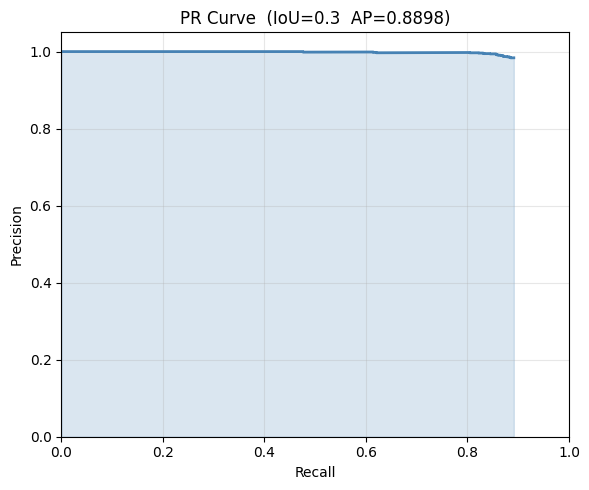

AP@IoU=0.5: 0.8669


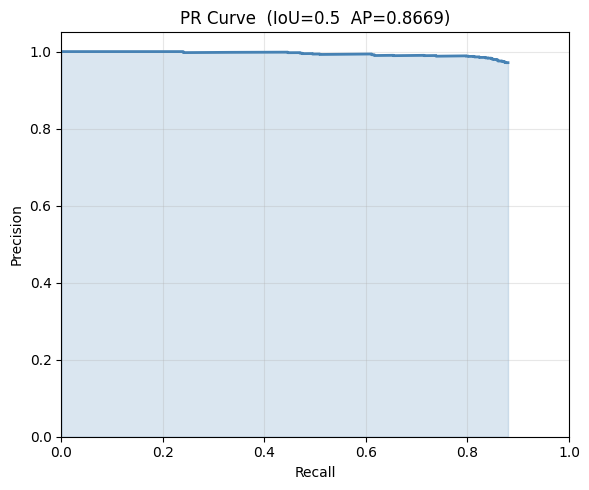

AP@IoU=0.7: 0.8299


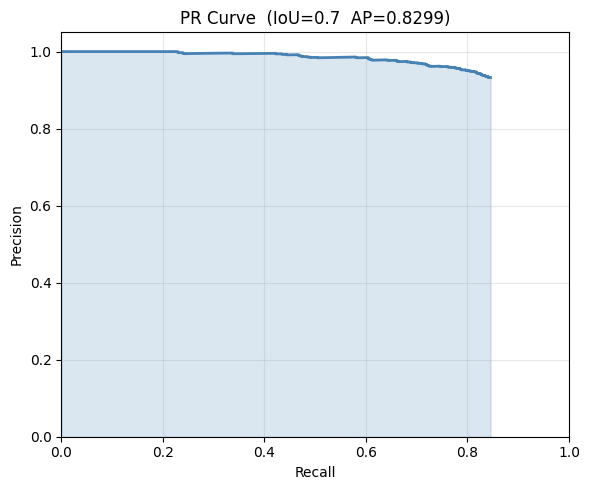


mAP@[0.5:0.95]: 0.6512


In [10]:
# AP @ IoU 0.3 / 0.5 / 0.7，並畫 PR curve
for iou_threshold in [0.3, 0.5, 0.7]:
    ap, recalls, precisions = calculate_ap(results_by_iou[iou_threshold])
    print(f"AP@IoU={iou_threshold}: {ap:.4f}")
    plot_pr_curve(recalls, precisions, ap, iou_threshold)

# mAP@[0.5:0.95] (COCO style)
aps = [calculate_ap(results_by_iou[iou])[0] for iou in iou_thresholds_map]
print(f"\nmAP@[0.5:0.95]: {np.mean(aps):.4f}")

In [11]:
# 彙整所有 metric 成一個 DataFrame
rows = []

for iou_threshold in iou_thresholds_report:
    ndf = results_by_iou[iou_threshold]

    # AP
    ap, _, _ = calculate_ap(ndf)

    # Image-wise
    img_df = get_image_metrics(ndf)
    img_recall    = img_df['recall'].mean()
    img_precision = img_df['precision'].mean()
    img_f1        = img_df['f1'].mean()

    # Patient-wise
    pat_df = get_patient_metrics(ndf)
    pat_recall    = pat_df['recall'].mean()
    pat_precision = pat_df['precision'].mean()
    pat_f1        = pat_df['f1'].mean()

    # Center distance (TP only)
    tp_dist = ndf.loc[ndf['match_type'] == 'TP', 'center_distance'].dropna()
    cd_mean   = tp_dist.mean()   if len(tp_dist) > 0 else None
    cd_median = tp_dist.median() if len(tp_dist) > 0 else None
    cd_std    = tp_dist.std()    if len(tp_dist) > 0 else None
    cd_max    = tp_dist.max()    if len(tp_dist) > 0 else None

    rows.append({
        'iou_threshold':      iou_threshold,
        'AP':                 round(ap, 4),
        'img_recall':         round(img_recall,    4),
        'img_precision':      round(img_precision, 4),
        'img_f1':             round(img_f1,        4),
        'patient_recall':     round(pat_recall,    4),
        'patient_precision':  round(pat_precision, 4),
        'patient_f1':         round(pat_f1,        4),
        'cd_mean':            round(cd_mean,   2) if cd_mean   is not None else None,
        'cd_median':          round(cd_median, 2) if cd_median is not None else None,
        'cd_std':             round(cd_std,    2) if cd_std    is not None else None,
        'cd_max':             round(cd_max,    2) if cd_max    is not None else None,
    })

# mAP@[0.5:0.95]
map_aps = [calculate_ap(results_by_iou[iou])[0] for iou in iou_thresholds_map]
mAP = round(float(np.mean(map_aps)), 4)

summary_df = pd.DataFrame(rows).set_index('iou_threshold')
summary_df.index.name = 'IoU'

print(f"mAP@[0.5:0.95]: {mAP}")
display(summary_df)

mAP@[0.5:0.95]: 0.6512


,AP,img_recall,img_precision,img_f1,patient_recall,patient_precision,patient_f1,cd_mean,cd_median,cd_std,cd_max
IoU,,,,,,,,,,,
0.3,0.8898,0.9210,0.9439,0.9267,0.9149,0.9695,0.9354,3.72,2.34,6.34,91.38
0.5,0.8669,0.9099,0.9317,0.9153,0.9074,0.9603,0.9274,3.30,2.32,4.56,79.85
0.7,0.8299,0.8761,0.8960,0.8811,0.8758,0.9251,0.8943,3.00,2.28,3.14,34.75


In [ ]:
summary_df.to_csv(f"../yolo_output/runs/detect/{name}/detailed_metrics.csv")

In [ ]:
# # 詳細的 image-wise / patient-wise 表格
# iou = 0.5
# nodule_df = results_by_iou[iou]

# img_df, pat_df = summarize(nodule_df)

# print("\n--- Image-wise ---")
# display(img_df.sort_values('f1'))

# print("\n--- Patient-wise ---")
# display(pat_df.sort_values('f1'))

In [ ]:
# # TP nodule 的 center distance 分析
# iou = 0.5
# tp_records = results_by_iou[iou][results_by_iou[iou]['match_type'] == 'TP']

# print(f"TP count: {len(tp_records)}")
# print(tp_records['center_distance'].describe())

In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def draw_boxes_on_image(image_path, records):
    """
    在圖片上畫出預測框與 GT 框。
    顏色規則:
      TP pred box  -> 綠色實線
      TP gt box    -> 綠色虛線
      FP pred box  -> 紅色實線
      FN gt box    -> 橘色虛線
    """
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img)

    for rec in records:
        mtype = rec['match_type']

        if mtype == 'TP':
            pred_box = rec['pred_box']
            gt_box   = rec['gt_box']
            # pred: 綠色實線
            ax.add_patch(patches.Rectangle(
                (pred_box[0], pred_box[1]),
                pred_box[2] - pred_box[0], pred_box[3] - pred_box[1],
                linewidth=2, edgecolor='lime', facecolor='none', linestyle='-'
            ))
            # gt: 綠色虛線
            ax.add_patch(patches.Rectangle(
                (gt_box[0], gt_box[1]),
                gt_box[2] - gt_box[0], gt_box[3] - gt_box[1],
                linewidth=2, edgecolor='lime', facecolor='none', linestyle='--'
            ))
            cd = rec['center_distance']
            ax.text(pred_box[0], pred_box[1] - 4,
                    f"TP cd={cd:.1f}", color='lime', fontsize=7)

        elif mtype == 'FP':
            pred_box = rec['pred_box']
            ax.add_patch(patches.Rectangle(
                (pred_box[0], pred_box[1]),
                pred_box[2] - pred_box[0], pred_box[3] - pred_box[1],
                linewidth=2, edgecolor='red', facecolor='none', linestyle='-'
            ))
            ax.text(pred_box[0], pred_box[1] - 4,
                    "FP", color='red', fontsize=7)

        elif mtype == 'FN':
            gt_box = rec['gt_box']
            ax.add_patch(patches.Rectangle(
                (gt_box[0], gt_box[1]),
                gt_box[2] - gt_box[0], gt_box[3] - gt_box[1],
                linewidth=2, edgecolor='orange', facecolor='none', linestyle='--'
            ))
            ax.text(gt_box[0], gt_box[1] - 4,
                    "FN", color='orange', fontsize=7)

    file_name = records[0]['file_name']
    tp = sum(1 for r in records if r['match_type'] == 'TP')
    fp = sum(1 for r in records if r['match_type'] == 'FP')
    fn = sum(1 for r in records if r['match_type'] == 'FN')
    ax.set_title(f"{file_name}\nTP={tp}  FP={fp}  FN={fn}", fontsize=9)
    ax.axis('off')

    # 圖例
    legend_elements = [
        patches.Patch(edgecolor='lime',   facecolor='none', linestyle='-',  label='TP pred'),
        patches.Patch(edgecolor='lime',   facecolor='none', linestyle='--', label='TP gt'),
        patches.Patch(edgecolor='red',    facecolor='none', linestyle='-',  label='FP pred'),
        patches.Patch(edgecolor='orange', facecolor='none', linestyle='--', label='FN gt'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=7)

    plt.tight_layout()
    return fig


def visualize_samples(nodule_df, data_root, iou_threshold=0.5,
                      n=16, mode='random', seed=42):
    """
    mode:
      'random'  - 隨機抽樣
      'fp'      - FP 最多的圖片
      'fn'      - FN 最多的圖片
      'worst'   - FP+FN 最多的圖片
    """
    # 按 file_name 分組
    grouped = nodule_df.groupby('file_name')

    if mode == 'random':
        rng = random.Random(seed)
        file_names = rng.sample(list(grouped.groups.keys()),
                                min(n, len(grouped)))
    else:
        counts = (
            nodule_df[nodule_df['match_type'].isin(['FP', 'FN'])]
            .groupby(['file_name', 'match_type']).size().unstack(fill_value=0)
        )
        for col in ['FP', 'FN']:
            if col not in counts:
                counts[col] = 0
        if mode == 'fp':
            file_names = counts['FP'].nlargest(n).index.tolist()
        elif mode == 'fn':
            file_names = counts['FN'].nlargest(n).index.tolist()
        else:  # worst
            file_names = (counts['FP'] + counts['FN']).nlargest(n).index.tolist()

    ncols = 4
    nrows = (len(file_names) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()

    for ax_i, fname in enumerate(file_names):
        records = grouped.get_group(fname).to_dict('records')
        image_path = os.path.join(data_root, fname)

        img = cv2.imread(image_path)
        if img is None:
            axes[ax_i].axis('off')
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[ax_i].imshow(img)

        for rec in records:
            mtype = rec['match_type']
            if mtype == 'TP':
                for box, color, ls in [(rec['pred_box'], 'lime', '-'),
                                        (rec['gt_box'],  'lime', '--')]:
                    axes[ax_i].add_patch(patches.Rectangle(
                        (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                        linewidth=2, edgecolor=color, facecolor='none', linestyle=ls
                    ))
                axes[ax_i].text(rec['pred_box'][0], rec['pred_box'][1] - 4,
                                f"TP cd={rec['center_distance']:.1f}",
                                color='lime', fontsize=7)
            elif mtype == 'FP':
                b = rec['pred_box']
                axes[ax_i].add_patch(patches.Rectangle(
                    (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                    linewidth=2, edgecolor='red', facecolor='none'
                ))
                axes[ax_i].text(b[0], b[1] - 4, "FP", color='red', fontsize=7)
            elif mtype == 'FN':
                b = rec['gt_box']
                axes[ax_i].add_patch(patches.Rectangle(
                    (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                    linewidth=2, edgecolor='orange', facecolor='none', linestyle='--'
                ))
                axes[ax_i].text(b[0], b[1] - 4, "FN", color='orange', fontsize=7)

        tp = sum(1 for r in records if r['match_type'] == 'TP')
        fp = sum(1 for r in records if r['match_type'] == 'FP')
        fn = sum(1 for r in records if r['match_type'] == 'FN')
        axes[ax_i].set_title(f"{fname}\nTP={tp}  FP={fp}  FN={fn}", fontsize=8)
        axes[ax_i].axis('off')

    for ax_i in range(len(file_names), len(axes)):
        axes[ax_i].axis('off')

    legend_elements = [
        patches.Patch(edgecolor='lime',   facecolor='none', linestyle='-',  label='TP pred'),
        patches.Patch(edgecolor='lime',   facecolor='none', linestyle='--', label='TP gt'),
        patches.Patch(edgecolor='red',    facecolor='none', linestyle='-',  label='FP pred'),
        patches.Patch(edgecolor='orange', facecolor='none', linestyle='--', label='FN gt'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10)
    plt.suptitle(f"IoU={iou_threshold} | mode={mode}", fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
# 調整 mode 來切換不同視角:
#   'random' - 隨機 16 張
#   'fp'     - FP 最多的 16 張
#   'fn'     - FN 最多的 16 張
#   'worst'  - FP+FN 合計最多的 16 張

iou = 0.3
visualize_samples(results_by_iou[iou], data_root, iou_threshold=iou,
                  n=100, mode='random')